# Comprehensive Data Analysis: HRP Database

This notebook performs a comprehensive data analysis on the HRP database, covering:
1. Setup and Connection
2. Senior Demographics
3. Measurement Volume and Types
4. Medical History Linkage
5. SOS Alert Analysis
6. Duplicate Analysis
7. Random Senior Samples

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

## 1. Setup and Connection

Connect to the HRP database and load the first 5 rows from each table to verify the schema.

### 1.1 Connect and display DB tables

In [2]:
db_path = '../db/hrp_data.db'
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

In [3]:
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = [row[0] for row in cursor.fetchall()]
print(f"Tables in database: {tables}\n")

Tables in database: ['seniors', 'measurements', 'sqlite_sequence', 'medical_info', 'diseases', 'medicines', 'senior_diseases', 'senior_medicines', 'alerts', 'ingestion_state']



### 1.2 Previewing major tables

In [4]:
table_list = ['seniors', 'measurements', 'alerts', 'senior_diseases', 'senior_medicines']
print(f"Previewing tables: {table_list}")

Previewing tables: ['seniors', 'measurements', 'alerts', 'senior_diseases', 'senior_medicines']


### 1.3 Overview of database tables

In [5]:
for table in table_list:
    try:
        df = pd.read_sql_query(f"SELECT * FROM {table} LIMIT 5", conn)
        total_rows = pd.read_sql_query(f"SELECT COUNT(*) as count FROM {table}", conn)['count'][0]
        print(80 * "=")
        print(f"Table: {table} (Total rows: {total_rows:,})")
        print(80 * "=")
        print(f"Columns: {list(df.columns)}")
        print(f"Data types:\n{df.dtypes}\n")
        print(df.to_string(index=False))
    except Exception as e:
        print(f"Error reading table {table}: {e}")

Table: seniors (Total rows: 13,317)
Columns: ['id', 'gender', 'birthdate', 'age']
Data types:
id            int64
gender       object
birthdate    object
age           int64
dtype: object

  id gender  birthdate  age
2875 Female 1955-02-26   70
3175 Female 1956-09-02   69
3176 Female 1934-08-11   91
3178   Male 1932-12-13   93
3179 Female 1941-11-04   84
Table: measurements (Total rows: 72,654,799)
Columns: ['id', 'senior_id', 'value', 'sbp', 'dbp', 'date', 'type']
Data types:
id             int64
senior_id      int64
value        float64
sbp           object
dbp           object
date          object
type          object
dtype: object

 id  senior_id  value  sbp  dbp                date        type
  1      48129   36.3 None None 2025-11-03 23:16:12 Temperature
  2      48427   36.6 None None 2025-11-03 23:16:12 Temperature
  3      45310   36.3 None None 2025-11-03 23:16:12 Temperature
  4      29421   36.6 None None 2025-11-03 23:16:12 Temperature
  5      45316   36.9 None None 2025

## 2. Senior Demographics

Analyze senior population statistics, NULL values, and age outliers.

### 2.1 Load seniors table into DataFrame

In [12]:
seniors_df = pd.read_sql_query("SELECT * FROM seniors", conn)

### 2.2 Senior data overview

In [7]:

total_seniors = len(seniors_df)
unique_senior_ids = seniors_df['id'].nunique()
print(f"Total seniors: {total_seniors}")
print(f"Unique senior ids: {unique_senior_ids}")

Total seniors: 13317
Unique senior ids: 13317


In [105]:
valid_genders = {'Male', 'Female'}
invalid_gender_rows = seniors_df[~seniors_df['gender'].isin(valid_genders)]
print(f"gender: {len(invalid_gender_rows)} UNKNOWN ({len(invalid_gender_rows)/total_seniors*100:.2f}%)")

null_counts = seniors_df[['birthdate', 'age']].isna().sum()
for col, count in null_counts.items():
    print(f"{col}: {count} NULLs ({count/total_seniors*100:.2f}%)")

gender: 95 UNKNOWN (0.71%)
birthdate: 264 NULLs (1.98%)
age: 249 NULLs (1.87%)


In [ ]:
invalid_gender_rows[['id', 'gender', 'age', 'birthdate']].head()

,id,gender,age,birthdate
1665,21379,Unknown,69.0,1956-11-26
1666,21380,Unknown,78.0,1947-02-19
1723,21602,Unknown,77.0,1948-11-14
1752,21853,Unknown,69.0,1956-10-19
2086,23496,Unknown,79.0,1946-03-18


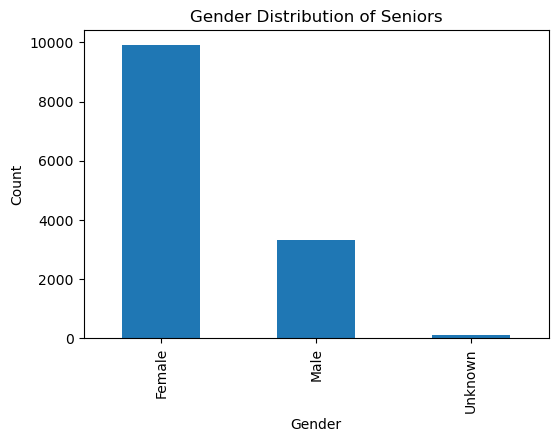

In [112]:
gender_counts = seniors_df['gender'].value_counts()
plt.figure(figsize=(6, 4))
gender_counts.plot(kind='bar')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender Distribution of Seniors')
plt.show()

In [79]:
print(f"Min age: {seniors_df['age'].min()}")
print(f"Max age: {seniors_df['age'].max()}")
print(f"Mean age: {seniors_df['age'].mean():.2f}")
print(f"Median age: {seniors_df['age'].median():.2f}")

Min age: -75.0
Max age: 125.0
Mean age: 76.17
Median age: 77.00


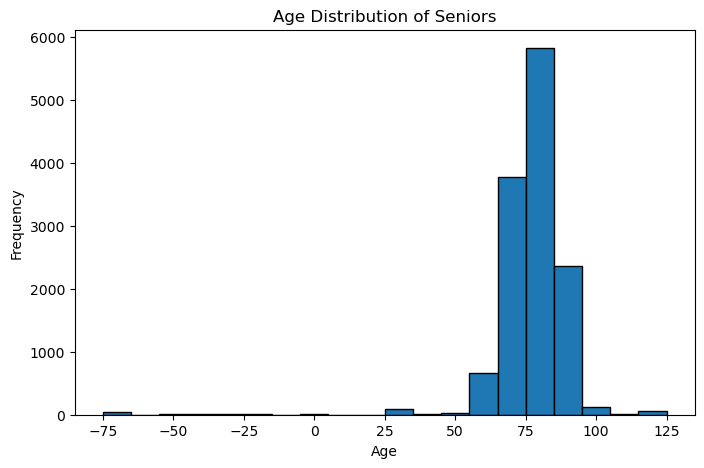

In [118]:
plt.figure(figsize=(8, 5))
plt.hist(seniors_df['age'].dropna(), bins=20, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution of Seniors')
plt.show()

### 2.3 Seniors age outlier analysis

In [ ]:
min_age = 50
max_age = 120

age_outliers = seniors_df[(seniors_df['age'] < min_age) | (seniors_df['age'] > max_age)]
print(f"Seniors with age < {min_age}: {len(seniors_df[seniors_df['age'] < min_age])}")
print(f"Seniors with age > {max_age}: {len(seniors_df[seniors_df['age'] > max_age])}")

Seniors with age < 50: 210
Seniors with age > 120: 60


In [103]:
age_outliers[['id', 'gender', 'birthdate', 'age']].head(10)

,id,gender,birthdate,age
802,12453,Female,2022-11-28,3.0
837,12894,Female,2023-01-09,2.0
936,13337,Female,2024-09-06,1.0
1204,18008,Female,2023-04-11,2.0
1775,21885,Female,1988-07-09,37.0
1791,21907,Male,2040-10-30,-15.0
1870,22042,Female,None,125.0
2067,23413,Female,None,125.0
2107,23663,Female,2066-08-14,-41.0
2218,23958,Female,1900-12-31,124.0


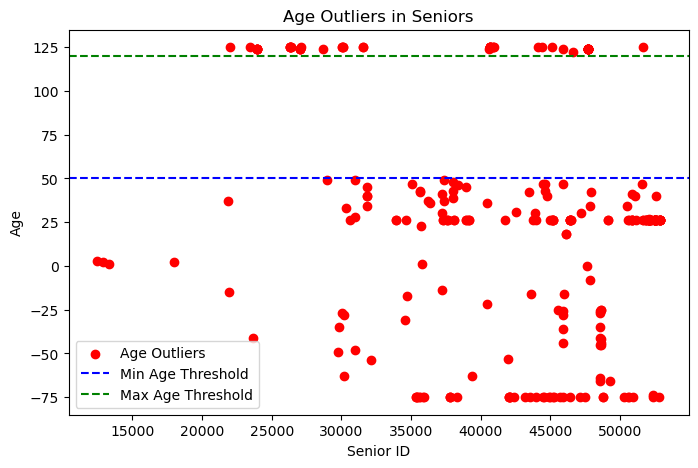

In [123]:
plt.figure(figsize=(8, 5))
plt.scatter(age_outliers['id'], age_outliers['age'], color='red', label='Age Outliers')
plt.axhline(y=min_age, color='blue', linestyle='--', label='Min Age Threshold')
plt.axhline(y=max_age, color='green', linestyle='--', label='Max Age Threshold')
plt.xlabel('Senior ID')
plt.ylabel('Age')
plt.title('Age Outliers in Seniors')
plt.legend()
plt.show()

## 3. Measurement Volume and Types
Analyze measurement distribution across types and date range.

### 3.1.1 Load measurements table into DataFrame

In [13]:
measurements_df = pd.read_sql_query("SELECT * FROM measurements", conn)

### 3.1.2 Measurements overview

The following cells contain: measurement type distribution, date range, vital signs analysis, and daily measurements statistics.

In [ ]:
type_counts = measurements_df['type'].value_counts().sort_values(ascending=False)
for col, count in type_counts.items():
    print(f"{col}: {count:,} measurements ({count/len(measurements_df)*100:.2f}%)")

Heartrate: 16,429,481 measurements (22.61%)
BloodPressure: 16,429,476 measurements (22.61%)
Temperature: 16,359,953 measurements (22.52%)
Saturation: 13,121,312 measurements (18.06%)
Steps: 10,314,577 measurements (14.20%)


In [ ]:
measurements_df['date'] = pd.to_datetime(measurements_df['date'], format='ISO8601')
min_date = measurements_df['date'].min()
max_date = measurements_df['date'].max()
print(f"Min date: {min_date}")
print(f"Max date: {max_date}")
print(f"Total days span: {(max_date - min_date).days} days")

Min date: 2025-11-01 00:00:02
Max date: 2025-11-30 23:59:59
Total days span: 29 days


In [ ]:
measurements_per_senior = measurements_df.groupby('senior_id').size()
print(f"Average measurements per senior: {measurements_per_senior.mean():.2f}")
print(f"Median measurements per senior: {measurements_per_senior.median():.2f}")
print(f"Min measurements per senior: {measurements_per_senior.min()}")
print(f"Max measurements per senior: {measurements_per_senior.max()}")
print(f"Std dev: {measurements_per_senior.std():.2f}")

Average measurements per senior: 5455.79
Median measurements per senior: 3524.00
Min measurements per senior: 1
Max measurements per senior: 64711
Std dev: 5767.18


In [ ]:
measurements_per_day = measurements_df.groupby(['senior_id', measurements_df['date'].dt.date]).size()
measurements_per_day_stats = measurements_per_day.groupby('senior_id').agg(['mean', 'std', 'min', 'max'])
measurements_per_day_stats.head(10)

,mean,std,min,max
senior_id,,,,
2875,306.625000,164.380209,8,515
3175,175.142857,70.033767,5,277
3176,75.136364,31.502525,10,131
3178,22.666667,17.179974,4,48
3179,17.714286,10.291004,4,32
3183,43.666667,34.355980,4,64
3184,61.000000,23.636131,44,96
3186,34.909091,23.319538,8,88
3188,46.266667,45.529373,4,165


In [13]:
stats = measurements_per_day_stats.copy()
stats = stats.reset_index()

### 3.1.3 Measurement Plots
The following are plots as in the form of histograms of mean and std across seniors, top 50 seniors by mean measurements/day with error bars for std, and line graph of total measurements per day.

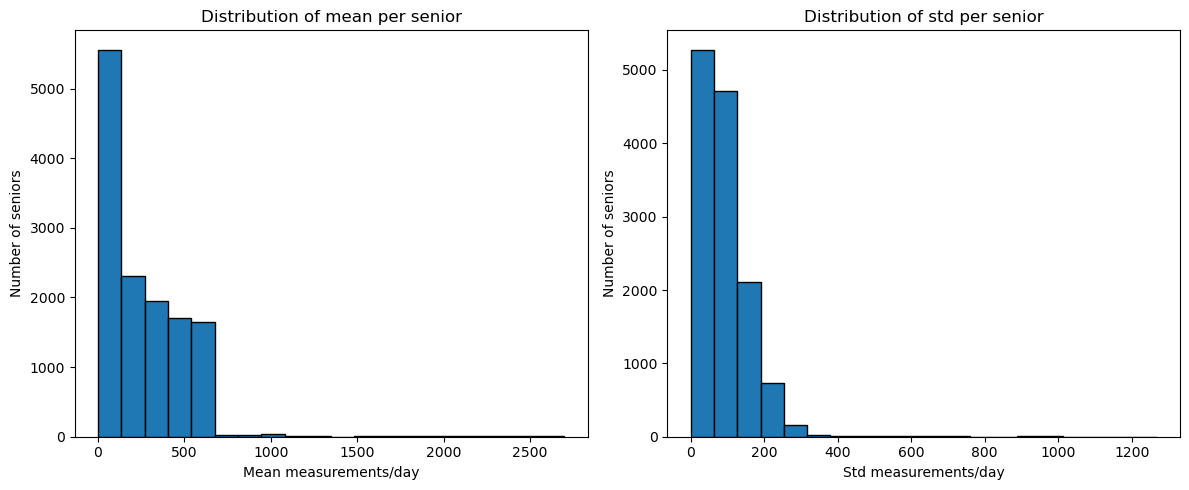

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(stats['mean'].dropna(), bins=20, edgecolor='black')
axes[0].set_xlabel('Mean measurements/day')
axes[0].set_ylabel('Number of seniors')
axes[0].set_title('Distribution of mean per senior')
axes[1].hist(stats['std'].dropna(), bins=20, edgecolor='black')
axes[1].set_xlabel('Std measurements/day')
axes[1].set_ylabel('Number of seniors')
axes[1].set_title('Distribution of std per senior')
plt.tight_layout()
plt.show()

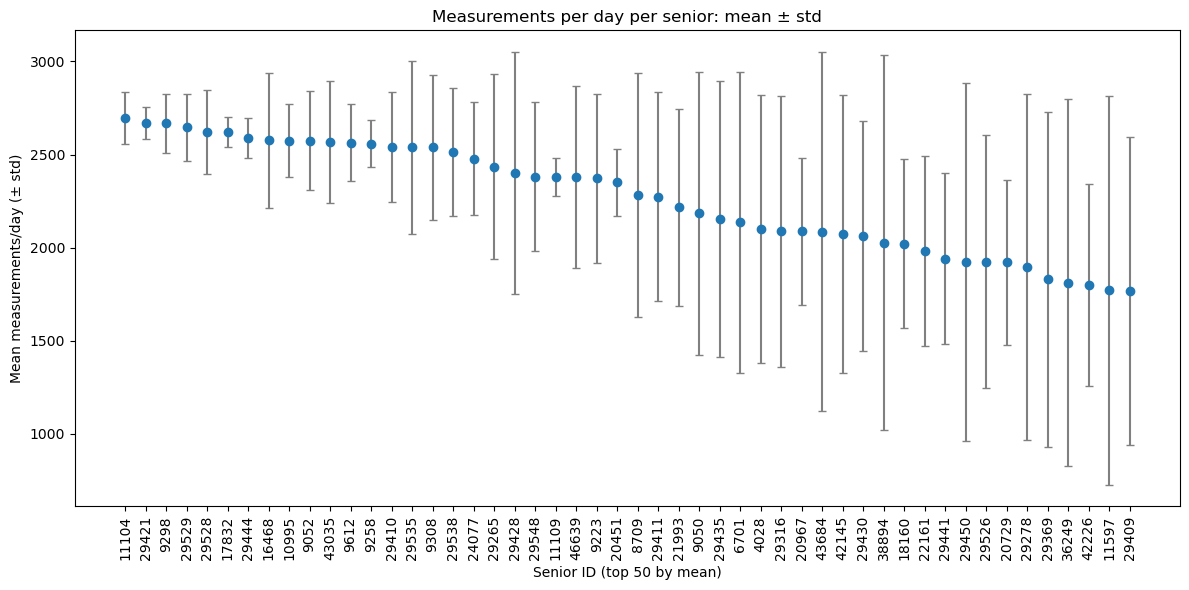

In [ ]:
top = stats.sort_values('mean', ascending=False).head(50)
x = np.arange(len(top))
plt.figure(figsize=(12, 6))
plt.errorbar(x, top['mean'], yerr=top['std'], fmt='o', ecolor='gray', capsize=3, color='tab:blue')
plt.xticks(x, top['senior_id'].astype(str), rotation=90)
plt.xlabel('Senior ID (top 50 by mean)')
plt.ylabel('Mean measurements/day (± std)')
plt.title('Measurements per day per senior: mean ± std')
plt.tight_layout()
plt.show()

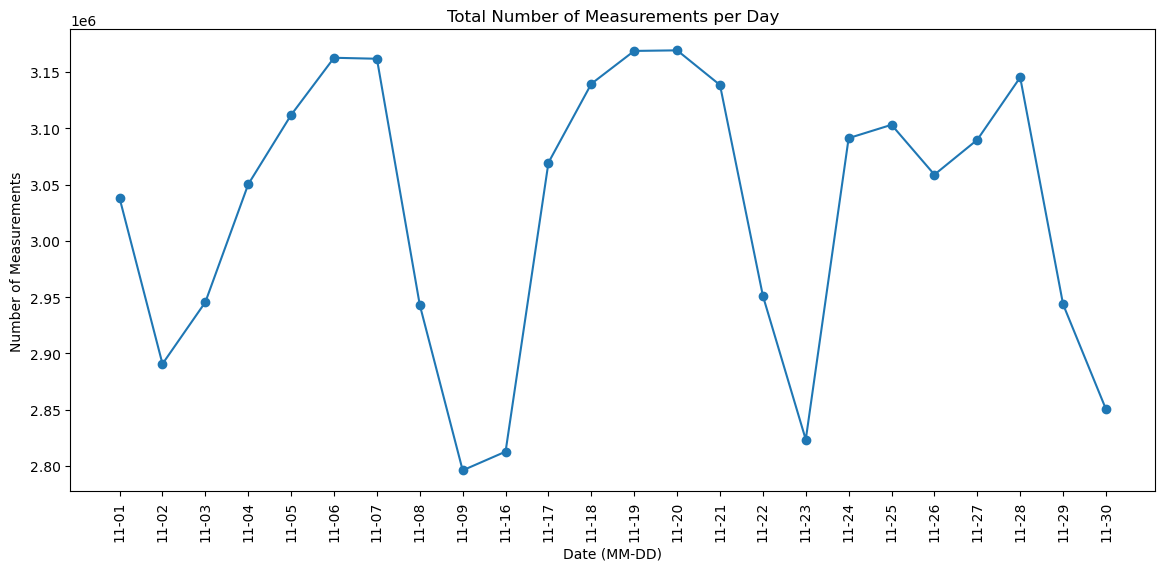

In [ ]:
measurements_per_day_total = measurements_df.groupby(measurements_df['date'].dt.date).size()
measurements_per_day_total.index = measurements_per_day_total.index.map(lambda d: d.strftime('%m-%d'))
plt.figure(figsize=(14, 6))
plt.plot(measurements_per_day_total.index, measurements_per_day_total.values, marker='o', linestyle='-')
plt.xticks(rotation=90)
plt.title('Total Number of Measurements per Day')
plt.xlabel('Date (MM-DD)')
plt.ylabel('Number of Measurements')
plt.show()

## 3.2 Measurement Type Analysis
Analyze vital signs, find outliers, and correlation between types.

In [18]:
vital_types = measurements_df['type'].unique()
vital_stats = {}

### 3.2.1 Vital Sign Statistics

In [ ]:
bp_df = measurements_df[measurements_df['type'] == 'BloodPressure']

sbp_stats = {
    'min': bp_df['sbp'].min(),
    'max': bp_df['sbp'].max(),
    'mean': bp_df['sbp'].mean(),
    'std': bp_df['sbp'].std()
}

dbp_stats = {
    'min': bp_df['dbp'].min(),
    'max': bp_df['dbp'].max(),
    'mean': bp_df['dbp'].mean(),
    'std': bp_df['dbp'].std()
}

print("\nBloodPressure (SBP):")
print(f"  Min: {sbp_stats['min']:.2f}")
print(f"  Max: {sbp_stats['max']:.2f}")
print(f"  Mean: {sbp_stats['mean']:.2f}")
print(f"  Std: {sbp_stats['std']:.2f}")

print("\nBloodPressure (DBP):")
print(f"  Min: {dbp_stats['min']:.2f}")
print(f"  Max: {dbp_stats['max']:.2f}")
print(f"  Mean: {dbp_stats['mean']:.2f}")
print(f"  Std: {dbp_stats['std']:.2f}")


for vital in sorted(vital_types):
    if vital == 'BloodPressure':
        continue

    vital_data = measurements_df[measurements_df['type'] == vital]['value']
    print(f"\n{vital}:")
    print(f"  Min: {vital_data.min():.2f}")
    print(f"  Max: {vital_data.max():.2f}")
    print(f"  Mean: {vital_data.mean():.2f}")
    print(f"  Std: {vital_data.std():.2f}")


BloodPressure (SBP):
  Min: 68.00
  Max: 212.00
  Mean: 129.46
  Std: 11.90

BloodPressure (DBP):
  Min: 23.00
  Max: 157.00
  Mean: 78.69
  Std: 8.88

Heartrate:
  Min: 5.00
  Max: 210.00
  Mean: 73.39
  Std: 17.79

Saturation:
  Min: 80.00
  Max: 100.00
  Mean: 97.06
  Std: 3.32

Steps:
  Min: 1.00
  Max: 50147.00
  Mean: 3107.78
  Std: 3141.20

Temperature:
  Min: 36.20
  Max: 127.90
  Mean: 36.71
  Std: 3.03


### 3.2.2 Impossible values checks (outliers)

In [42]:
# Impossible values checks
temp_min = 30
temp_max = 45
SBP_min = 70
SBP_max = 250
DBP_min = 40
DBP_max = 140
saturation_min = 50
HR_min = 30
HR_max = 220

In [44]:
temp_data = measurements_df[measurements_df['type'] == 'Temperature']['value']
temp_impossible = len(temp_data[(temp_data > temp_max) | (temp_data < temp_min)])
print(f"Temperature > {temp_max}°C or < {temp_min}°C: {temp_impossible}")

saturation_data = measurements_df[measurements_df['type'] == 'Saturation']['value']
saturation_impossible = len(saturation_data[saturation_data < saturation_min])
print(f"Saturation < {saturation_min}%: {saturation_impossible}")

hr_data = measurements_df[measurements_df['type'] == 'Heartrate']['value']
hr_impossible = len(hr_data[(hr_data > HR_max) | (hr_data < HR_min)])
print(f"Heart Rate > {HR_max} bpm or < {HR_min} bpm: {hr_impossible}")

sbp_data = bp_df['sbp']
sbp_impossible = len(sbp_data[(sbp_data > SBP_max) | (sbp_data < SBP_min)])
print(f"SBP > {SBP_max} or < {SBP_min} mmHg: {sbp_impossible}")

dbp_data = bp_df['dbp']
dbp_impossible = len(dbp_data[(dbp_data > DBP_max) | (dbp_data < DBP_min)])
print(f"DBP > {DBP_max} or < {DBP_min} mmHg: {dbp_impossible}")

Temperature > 45°C or < 30°C: 18616
Saturation < 50%: 0
Heart Rate > 220 bpm or < 30 bpm: 10
SBP > 250 or < 70 mmHg: 394
DBP > 140 or < 40 mmHg: 6855


### 3.2.3 Blood Pressure distribution plot

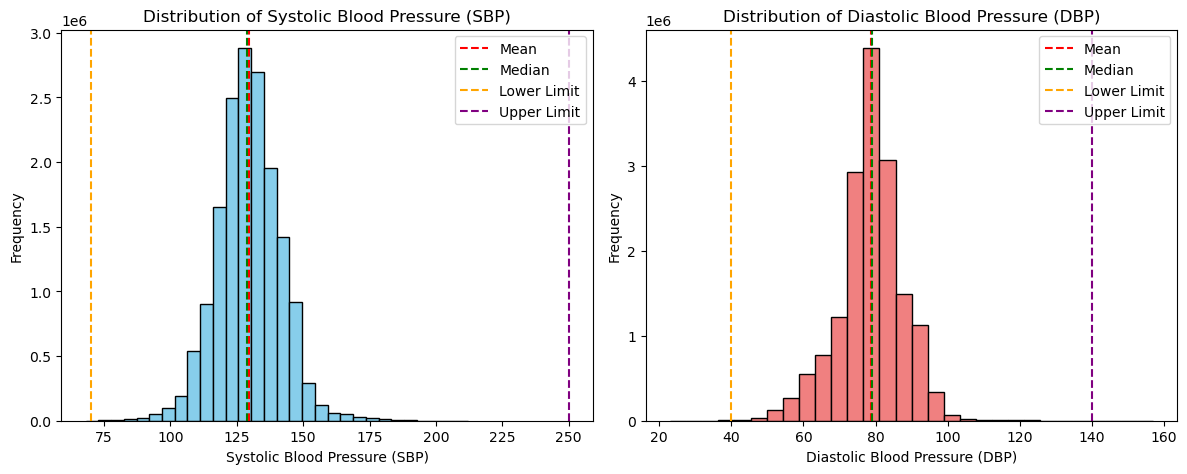

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(bp_df['sbp'], bins=30, color='skyblue', edgecolor='black')
plt.axvline(bp_df['sbp'].mean(), color='red', linestyle='dashed', label='Mean')
plt.axvline(bp_df['sbp'].median(), color='green', linestyle='dashed', label='Median')
plt.axvline(SBP_min, color='orange', linestyle='dashed', label='Lower Limit')
plt.axvline(SBP_max, color='purple', linestyle='dashed', label='Upper Limit')
plt.xlabel('Systolic Blood Pressure (SBP)')
plt.ylabel('Frequency')
plt.title('Distribution of Systolic Blood Pressure (SBP)')
plt.legend()
plt.subplot(1, 2, 2)
plt.hist(bp_df['dbp'], bins=30, color='lightcoral', edgecolor='black')
plt.axvline(bp_df['dbp'].mean(), color='red', linestyle='dashed', label='Mean')
plt.axvline(bp_df['dbp'].median(), color='green', linestyle='dashed', label='Median')
plt.axvline(DBP_min, color='orange', linestyle='dashed', label='Lower Limit')
plt.axvline(DBP_max, color='purple', linestyle='dashed', label='Upper Limit')
plt.xlabel('Diastolic Blood Pressure (DBP)')
plt.ylabel('Frequency')
plt.title('Distribution of Diastolic Blood Pressure (DBP)')
plt.legend()
plt.tight_layout()
plt.show()

### 3.2.4 Heart Rate distribution plot

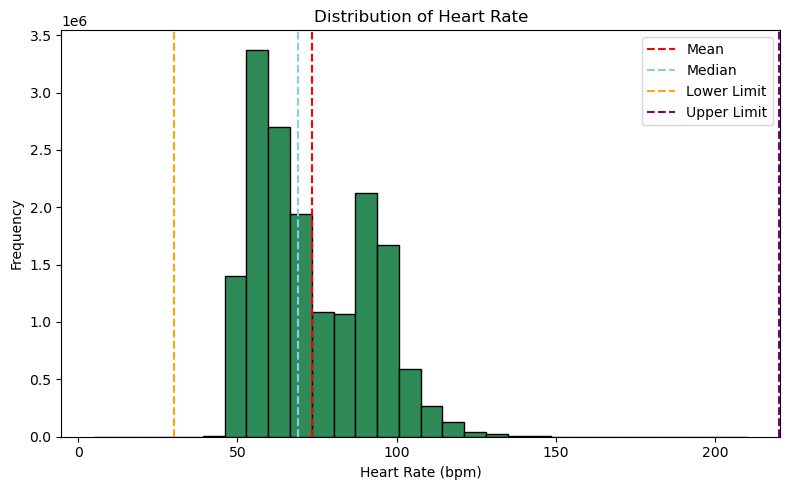

In [ ]:
hr_df = measurements_df[measurements_df['type'] == 'Heartrate']
plt.figure(figsize=(8, 5))
plt.hist(hr_df['value'], bins=30, color='seagreen', edgecolor='black')
plt.axvline(hr_df['value'].mean(), color='red', linestyle='dashed', label='Mean')
plt.axvline(hr_df['value'].median(), color='skyblue', linestyle='dashed', label='Median')
plt.axvline(HR_min, color='orange', linestyle='dashed', label='Lower Limit')
plt.axvline(HR_max, color='purple', linestyle='dashed', label='Upper Limit')
plt.xlabel('Heart Rate (bpm)')
plt.ylabel('Frequency')
plt.title('Distribution of Heart Rate')
plt.legend()
plt.tight_layout()
plt.show()

### 3.2.5 Scatter plot SBP vs DBP

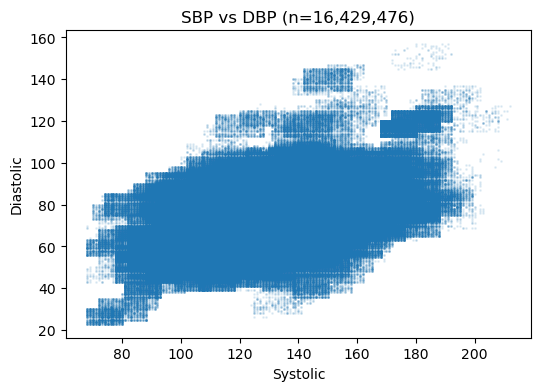

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(bp_df['sbp'], bp_df['dbp'], alpha=0.1, s=1)
plt.title(f"SBP vs DBP (n={len(bp_df):,})")
plt.xlabel("Systolic")
plt.ylabel("Diastolic")
plt.show()

### 3.2.6 Create wide-format DataFrame

In [ ]:
bp_df = measurements_df[measurements_df['type'] == 'BloodPressure'][
    ['senior_id', 'date', 'sbp', 'dbp']
]

other_df = measurements_df[measurements_df['type'] != 'BloodPressure'][
    ['senior_id', 'date', 'type', 'value']
]

other_pivot = other_df.pivot_table(
    index=['senior_id', 'date'],
    columns='type',
    values='value',
    aggfunc='mean'
)

bp_pivot = bp_df.set_index(['senior_id', 'date'])[['sbp', 'dbp']]
bp_pivot.columns = ['SBP', 'DBP']

wide_df = other_pivot.join(bp_pivot, how='inner')
wide_df.head()

Heartrate  Saturation  Steps  Temperature  \
senior_id date                                                             
2875      2025-11-01 10:12:11      107.0         NaN    NaN         36.6   
          2025-11-01 10:52:11       94.0        99.0    NaN         36.6   
          2025-11-01 12:12:11      106.0         NaN    NaN         36.6   
          2025-11-01 12:22:11       91.0         NaN    NaN         36.6   
          2025-11-01 12:32:11      111.0         NaN    NaN         36.5   

                                 SBP   DBP  
senior_id date                              
2875      2025-11-01 10:12:11  126.0  87.0  
          2025-11-01 10:52:11  113.0  85.0  
          2025-11-01 12:12:11  130.0  80.0  
          2025-11-01 12:22:11  125.0  82.0  
          2025-11-01 12:32:11  130.0  85.0

### 3.2.7 Correlation matrix of vital signs

In [63]:
corr_matrix = wide_df.corr()
print(corr_matrix)

             Heartrate  Saturation     Steps  Temperature       SBP       DBP
Heartrate     1.000000    0.214371  0.074179    -0.002808  0.278434  0.246989
Saturation    0.214371    1.000000  0.023947    -0.001932  0.043819  0.040539
Steps         0.074179    0.023947  1.000000    -0.010330  0.011137  0.025446
Temperature  -0.002808   -0.001932 -0.010330     1.000000 -0.003040  0.001859
SBP           0.278434    0.043819  0.011137    -0.003040  1.000000  0.400547
DBP           0.246989    0.040539  0.025446     0.001859  0.400547  1.000000


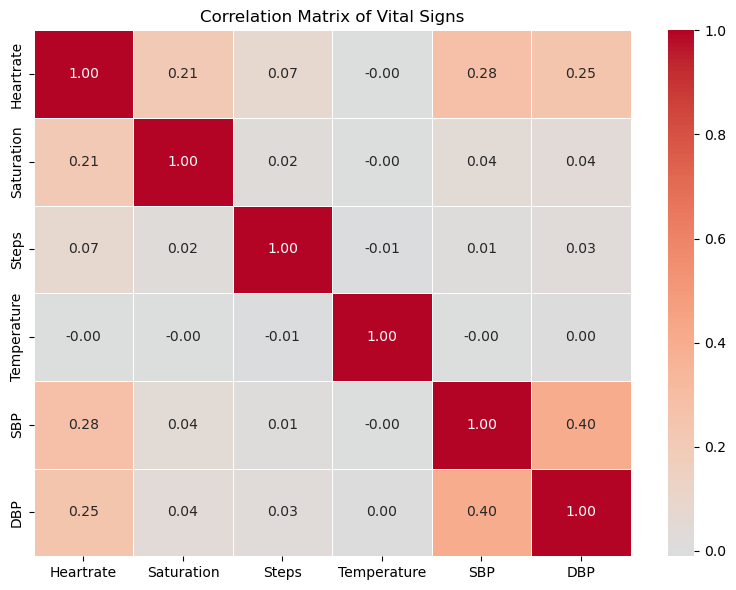

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Matrix of Vital Signs")
plt.tight_layout()
plt.show()

## 4. Medical History Linkage

Analyze disease and medication coverage.

### 4.1 Load disease and medicine data

In [9]:
diseases_df = pd.read_sql_query("SELECT * FROM senior_diseases", conn)
medicines_df = pd.read_sql_query("SELECT * FROM senior_medicines", conn)
diseases_lookup = pd.read_sql_query("SELECT * FROM diseases", conn)
medicines_lookup = pd.read_sql_query("SELECT * FROM medicines", conn)

### 4.2 Disease linkage

In [ ]:
seniors_with_disease = diseases_df['senior_id'].nunique()
disease_coverage = seniors_with_disease / total_seniors * 100
print(f"Seniors with at least one disease: {seniors_with_disease} ({disease_coverage:.2f}%)")
print(f"Total disease records: {len(diseases_df)}")
print(f"Avg diseases per senior (with diseases): {len(diseases_df) / seniors_with_disease:.2f}")

Seniors with at least one disease: 8220 (61.73%)
Total disease records: 49444
Avg diseases per senior (with diseases): 6.02


### 4.3 Medication linkage

In [ ]:
seniors_with_medicine = medicines_df['senior_id'].nunique()
medicine_coverage = seniors_with_medicine / total_seniors * 100
print(f"Seniors with at least one medication: {seniors_with_medicine} ({medicine_coverage:.2f}%)")
print(f"Total medication records: {len(medicines_df)}")
print(f"Avg medications per senior (with meds): {len(medicines_df) / seniors_with_medicine:.2f}")

Seniors with at least one medication: 8220 (61.73%)
Total medication records: 48304
Avg medications per senior (with meds): 5.88


## 5. Alert Analysis

Based on alert notes, analyze and categorize alerts into 4 levels: 

- **Level 0:** Noise/Technical - Accidental presses or system checks. Keywords include: `przypadkowy`, `testowy`, `techniczny`, `test`
- **Level 1:** Low - Human verified that the senior is (likely) okay. Keywords include: `nawiązano kontakt`, `opiekun powiadomiony`, `brak wskazań do interwencji zrm`
- **Level 2:** Potential/Unknown - No one spoke to the senior. High uncertainty. Keywords include: `nie nawiązano kontaktu`
- **Level 3:** Acute - Highest priority. If these exist, it's a crisis. Keywords include: `interwencja zrm`, `zagrożenia życia i zdrowia`, `zdecydowano wezwać zrm`

### 5.1 Load alerts table into DataFrame

In [5]:
alerts_df = pd.read_sql_query("SELECT * FROM alerts", conn)
alerts_df['alert_date'] = pd.to_datetime(alerts_df['alert_date'], format='ISO8601')

### 5.2 Number of alerts and unique seniors with alerts

In [6]:
total_alerts = len(alerts_df)
unique_seniors_with_alerts = alerts_df['senior_id'].nunique()
print(f"Total alerts: {total_alerts}")
print(f"Unique seniors with alerts: {unique_seniors_with_alerts}")

Total alerts: 5420
Unique seniors with alerts: 3062


In [7]:
alerts_df.head()

,alert_id,senior_id,alert_date,sos_note
0,1,3205,2025-11-30 17:07:51,Alarm przypadkowy
1,2,3221,2025-11-25 19:38:36,Alarm przypadkowy
2,3,3275,2025-11-14 15:01:34,Alarm przypadkowy
3,4,3279,2025-11-09 11:58:31,Alarm przypadkowy
4,5,3283,2025-11-17 18:44:32,Alarm przypadkowy


### 5.3 Classify alerts based on notes 

In [8]:
def classify_severity(note):
    if pd.isna(note):
        return 0

    note_l = str(note).lower()

    if any(k in note_l for k in ['alarm przypadkowy', 'alarm testowy', 'alert techniczny']):
        return 0

    no_zrm = 'brak wskazań do interwencji zrm' in note_l

    if (not no_zrm and (
            'zdecydowano się na interwencję zrm' in note_l or
            'zdecydowano wezwać zrm' in note_l or
            'wezwanie zrm' in note_l or 
            (
                'zagrożenia życia i zdrowia' in note_l and 
                'nawiązano kontakt' in note_l
            ) 
            or
            (
                'na podstawie odczytów z systemu' in note_l and
                'zrm' in note_l
            )
        )
    ):
        return 3

    if 'nie nawiązano kontaktu' in note_l:
        return 2

    if ('nawiązano kontakt' in note_l or'opiekun powiadomiony' in note_l):
        return 1

    return 0


In [9]:
alerts_df['severity'] = alerts_df['sos_note'].apply(classify_severity)

severity_map = {
    0: "0: Noise/Tech",
    1: "1: Low Risk",
    2: "2: Potential/Unknown",
    3: "3: Acute Crisis"
}
alerts_df['severity_label'] = alerts_df['severity'].map(severity_map)

### 5.4 Final severity classification

In [10]:
summary = alerts_df.groupby(['severity_label', 'sos_note']).size().reset_index(name='count')
summary.sort_values('severity_label', ascending=False)

,severity_label,sos_note,count
7,3: Acute Crisis,Alarm. Nawiązano kontakt z Seniorem. W wyniku ...,71
8,3: Acute Crisis,Alarm. Nie nawiązano kontaktu z seniorem i opi...,2
5,2: Potential/Unknown,Alarm. Nie nawiązano kontaktu z Seniorem i opi...,188
6,2: Potential/Unknown,Alarm. Nie nawiązano kontaktu z Seniorem. Opie...,134
3,1: Low Risk,Alarm. Nawiązano kontakt z Seniorem. Opiekun p...,48
4,1: Low Risk,Alarm. Nawiązano kontakt z Seniorem. W wyniku ...,137
0,0: Noise/Tech,Alarm przypadkowy,3701
1,0: Noise/Tech,Alarm testowy,1015
2,0: Noise/Tech,Alert techniczny,39


### 5.5 Final severity distribution

In [11]:
summary = alerts_df['severity_label'].value_counts().reset_index()
summary.columns = ['severity_label', 'count']
summary['percentage'] = (summary['count'] / summary['count'].sum()) * 100
summary['percentage'] = summary['percentage'].round(2)
summary

,severity_label,count,percentage
0,0: Noise/Tech,4840,89.30
1,2: Potential/Unknown,322,5.94
2,1: Low Risk,185,3.41
3,3: Acute Crisis,73,1.35


# 6. Duplicate Analysis

## 6.1 Duplicate `measurements` Table

### 6.1.1 Find measurements with the same senior_id, date, and type.

In [10]:
duplicate_groups = measurements_df.groupby(['senior_id', 'date', 'type']).size().reset_index(name='count')
duplicates = duplicate_groups[duplicate_groups['count'] > 1]

In [11]:
total_duplicate_groups = len(duplicates)
total_duplicate_rows = duplicates['count'].sum()

print(f"Total measurement rows: {len(measurements_df):,}")
print(f"Groups with duplicates (same senior_id, date, type): {total_duplicate_groups:,}")
print(f"Total duplicate measurement rows: {total_duplicate_rows:,}")
print(f"Percentage of measurements that are duplicates: {(total_duplicate_rows/len(measurements_df)*100):.2f}%")

Total measurement rows: 72,654,799
Groups with duplicates (same senior_id, date, type): 810
Total duplicate measurement rows: 1,622
Percentage of measurements that are duplicates: 0.00%


### 6.1.2 True vs Conflicting duplicates

Analyze whether duplicates have the same value (true duplicates) or different values (conflicting data).

In [ ]:
# Extract duplicate rows
duplicates['key'] = duplicates['senior_id'].astype(str) + "_" + \
                   duplicates['date'].astype(str) + "_" + \
                   duplicates['type'].astype(str)

measurements_df['key'] = measurements_df['senior_id'].astype(str) + "_" + \
                        measurements_df['date'].astype(str) + "_" + \
                        measurements_df['type'].astype(str)

dup_rows_df = measurements_df[measurements_df['key'].isin(duplicates['key'])].copy()

In [ ]:
# Analyze duplicates
non_bp_dups = dup_rows_df[dup_rows_df['type'] != 'BloodPressure']
if not non_bp_dups.empty:
    non_bp_counts = non_bp_dups.groupby(['senior_id', 'date', 'type'])['value'].nunique()
    true_dup_non_bp = (non_bp_counts == 1).sum()
    conflicting_non_bp = (non_bp_counts > 1).sum()
else:
    true_dup_non_bp = conflicting_non_bp = 0

bp_dups = dup_rows_df[dup_rows_df['type'] == 'BloodPressure']
if not bp_dups.empty:
    bp_counts = bp_dups.groupby(['senior_id', 'date', 'type']).agg({'sbp': 'nunique', 'dbp': 'nunique'})
    true_dup_bp = ((bp_counts['sbp'] == 1) & (bp_counts['dbp'] == 1)).sum()
    conflicting_bp = ((bp_counts['sbp'] > 1) | (bp_counts['dbp'] > 1)).sum()
else:
    true_dup_bp = conflicting_bp = 0

In [15]:
print(f"Total Duplicate Groups: {total_duplicate_groups}")
print(f"True Duplicates (Exact matches): {true_dup_non_bp + true_dup_bp}")
print(f"Conflicting Duplicates (Different values): {conflicting_non_bp + conflicting_bp}")

measurements_df.drop(columns=['key'], inplace=True)

Total Duplicate Groups: 810
True Duplicates (Exact matches): 107
Conflicting Duplicates (Different values): 703


### 6.1.3 Duplicates by measurement type

Analyze which measurement types have the most duplicates.

In [16]:
def check_group(group):
    mtype = group['type'].iloc[0]
    if mtype == 'BloodPressure':
        is_true = (group['sbp'].nunique() == 1) and (group['dbp'].nunique() == 1)
    else:
        is_true = (group['value'].nunique() == 1)
    
    return 'True Duplicate' if is_true else 'Conflicting'

In [20]:
group_categories = dup_rows_df.groupby(['senior_id', 'date', 'type']).apply(check_group).reset_index(name='category')
type_summary_df = duplicates.merge(group_categories, on=['senior_id', 'date', 'type'])

type_summary = type_summary_df.groupby('type').agg(
    total_duplicate_rows=('count', 'sum'),
    total_groups=('count', 'count'),
    true_duplicate_groups=('category', lambda x: (x == 'True Duplicate').sum()),
    conflicting_groups=('category', lambda x: (x == 'Conflicting').sum())
).sort_values('total_duplicate_rows', ascending=False)

type_summary

,total_duplicate_rows,total_groups,true_duplicate_groups,conflicting_groups
type,,,,
BloodPressure,607,303,0,303
Heartrate,607,303,41,262
Temperature,246,123,41,82
Saturation,142,71,25,46
Steps,20,10,0,10


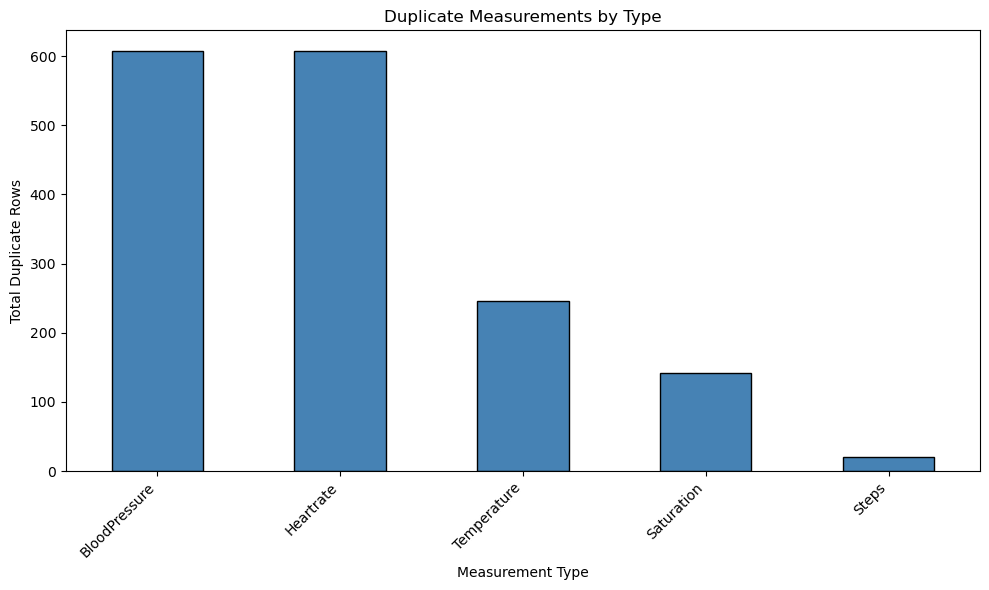

In [21]:
plt.figure(figsize=(10, 6))
type_summary['total_duplicate_rows'].plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Measurement Type')
plt.ylabel('Total Duplicate Rows')
plt.title('Duplicate Measurements by Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 6.1.4 Example duplicate entries

Display sample duplicate entries for review.

In [25]:
true_dup_keys = group_categories[group_categories['category'] == 'True Duplicate'].head(3)

for _, row in true_dup_keys.iterrows():
    example_data = dup_rows_df[
        (dup_rows_df['senior_id'] == row['senior_id']) & 
        (dup_rows_df['date'] == row['date']) & 
        (dup_rows_df['type'] == row['type'])
    ]
    
    print(f"\nGroup: Senior {row['senior_id']} | Date: {row['date']} | Type: {row['type']}")
    
    if row['type'] == 'BloodPressure':
        cols = ['senior_id', 'date', 'type', 'sbp', 'dbp']
    else:
        cols = ['senior_id', 'date', 'type', 'value']
        
    print(example_data[cols].to_string(index=False))


Group: Senior 8965 | Date: 2025-11-24 13:32:11 | Type: Heartrate
 senior_id                date      type  value
      8965 2025-11-24 13:32:11 Heartrate   78.0
      8965 2025-11-24 13:32:11 Heartrate   78.0

Group: Senior 9052 | Date: 2025-11-02 18:25:38 | Type: Heartrate
 senior_id                date      type  value
      9052 2025-11-02 18:25:38 Heartrate   56.0
      9052 2025-11-02 18:25:38 Heartrate   56.0

Group: Senior 9052 | Date: 2025-11-08 15:23:03 | Type: Temperature
 senior_id                date        type  value
      9052 2025-11-08 15:23:03 Temperature   36.6
      9052 2025-11-08 15:23:03 Temperature   36.6


In [26]:
conflict_dup_keys = group_categories[group_categories['category'] == 'Conflicting'].head(3)

for _, row in conflict_dup_keys.iterrows():
    example_data = dup_rows_df[
        (dup_rows_df['senior_id'] == row['senior_id']) & 
        (dup_rows_df['date'] == row['date']) & 
        (dup_rows_df['type'] == row['type'])
    ]
    
    print(f"\nGroup: Senior {row['senior_id']} | Date: {row['date']} | Type: {row['type']}")
    
    if row['type'] == 'BloodPressure':
        cols = ['senior_id', 'date', 'type', 'sbp', 'dbp']
    else:
        cols = ['senior_id', 'date', 'type', 'value']
        
    print(example_data[cols].to_string(index=False))


Group: Senior 3178 | Date: 2025-11-04 08:00:26 | Type: BloodPressure
 senior_id                date          type   sbp  dbp
      3178 2025-11-04 08:00:26 BloodPressure 164.0 81.0
      3178 2025-11-04 08:00:26 BloodPressure 165.0 82.0

Group: Senior 3178 | Date: 2025-11-04 08:00:26 | Type: Heartrate
 senior_id                date      type  value
      3178 2025-11-04 08:00:26 Heartrate   95.0
      3178 2025-11-04 08:00:26 Heartrate   78.0

Group: Senior 3348 | Date: 2025-11-06 11:24:12 | Type: BloodPressure
 senior_id                date          type   sbp  dbp
      3348 2025-11-06 11:24:12 BloodPressure 133.0 91.0
      3348 2025-11-06 11:24:12 BloodPressure 136.0 90.0


## 6.2 Duplicate `alerts` Table

### 6.2.1 Temporal Burst Analysis

Find cases where the same senior has multiple alerts within 10 minutes of each other. These may need to be merged into single 'Events' for ML modeling.

In [96]:
burst_threshold_minutes = 10
# TODO: Consider event_size as a feature (number of alerts in burst)

alerts_sorted = alerts_df.sort_values(['senior_id', 'alert_date']).reset_index(drop=True)
alerts_sorted['time_diff'] = alerts_sorted.groupby('senior_id')['alert_date'].diff()
alerts_sorted['time_diff_minutes'] = alerts_sorted['time_diff'].dt.total_seconds() / 60

In [97]:
alerts_sorted.describe()

,alert_id,senior_id,alert_date,severity,time_diff,time_diff_minutes
count,5420.00000,5420.000000,5420,5420.000000,2358,2358.000000
mean,2710.50000,42191.084133,2025-11-15 16:21:08.955350272,0.193358,4 days 09:48:16.106022052,6348.268434
min,1.00000,3205.000000,2025-11-01 00:26:14,0.000000,0 days 00:00:00,0.000000
25%,1355.75000,36274.000000,2025-11-07 13:26:35,0.000000,0 days 00:54:58,54.966667
50%,2710.50000,46967.000000,2025-11-15 08:21:04,0.000000,1 days 23:04:43.500000,2824.725000
75%,4065.25000,51275.500000,2025-11-23 06:11:19.500000,0.000000,6 days 20:52:51.250000,9892.854167
max,5420.00000,52896.000000,2025-11-30 22:51:59,3.000000,28 days 08:10:21,40810.350000
std,1564.76356,11650.467117,NaN,0.596378,5 days 15:48:28.167410550,8148.469457


In [98]:
print(f"Total alerts: {len(alerts_sorted):,}")
print("Time difference statistics (minutes):")
print(alerts_sorted['time_diff_minutes'].describe())

Total alerts: 5,420
Time difference statistics (minutes):
count     2358.000000
mean      6348.268434
std       8148.469457
min          0.000000
25%         54.966667
50%       2824.725000
75%       9892.854167
max      40810.350000
Name: time_diff_minutes, dtype: float64


In [99]:
alerts_sorted['is_burst'] = (alerts_sorted['time_diff_minutes'] <= burst_threshold_minutes) & (alerts_sorted['time_diff_minutes'].notna())

burst_alerts = alerts_sorted[alerts_sorted['is_burst']]
total_burst_alerts = len(burst_alerts)
burst_percentage = (total_burst_alerts / len(alerts_sorted)) * 100

print(f"\nAlerts within {burst_threshold_minutes} minutes of previous alert (same senior): {total_burst_alerts:,}")
print(f"Percentage of all alerts: {burst_percentage:.2f}%")


Alerts within 10 minutes of previous alert (same senior): 463
Percentage of all alerts: 8.54%


### 6.2.2 Temporal Bursts by Severity Level

In [100]:
burst_by_severity = burst_alerts.groupby('severity_label').size().reset_index(name='burst_count')
burst_by_severity = burst_by_severity.sort_values('burst_count', ascending=False)

severity_totals = alerts_sorted.groupby('severity_label').size().reset_index(name='total_count')
burst_summary = burst_by_severity.merge(severity_totals, on='severity_label')
burst_summary['burst_percentage'] = (burst_summary['burst_count'] / burst_summary['total_count'] * 100).round(2)

burst_summary

,severity_label,burst_count,total_count,burst_percentage
0,0: Noise/Tech,377,4840,7.79
1,2: Potential/Unknown,50,322,15.53
2,1: Low Risk,26,185,14.05
3,3: Acute Crisis,10,73,13.70


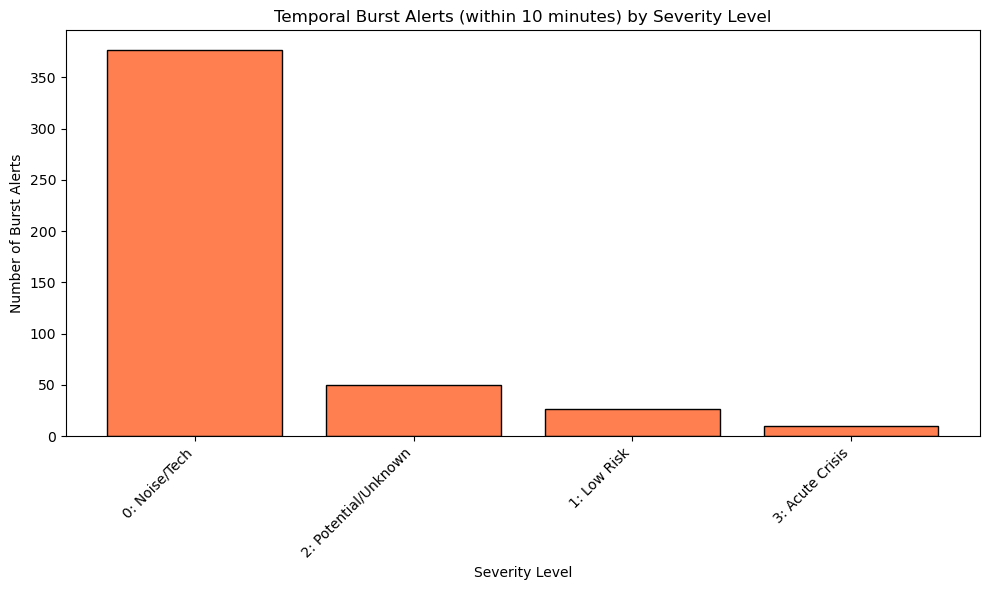

In [101]:
plt.figure(figsize=(10, 6))
plt.bar(burst_summary['severity_label'], burst_summary['burst_count'], color='coral', edgecolor='black')
plt.xlabel('Severity Level')
plt.ylabel('Number of Burst Alerts')
plt.title(f'Temporal Burst Alerts (within {burst_threshold_minutes} minutes) by Severity Level')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 6.2.3 Identify Alert Burst Events

Group consecutive alerts within 10 minutes into single events.

In [102]:
alerts_sorted['new_event'] = (~alerts_sorted['is_burst']).astype(int)
alerts_sorted['event_id'] = alerts_sorted.groupby('senior_id')['new_event'].cumsum()

alerts_sorted['unique_event_id'] = alerts_sorted['senior_id'].astype(str) + '_' + alerts_sorted['event_id'].astype(str)

In [103]:
total_events = alerts_sorted['unique_event_id'].nunique()
total_alerts = len(alerts_sorted)
events_with_bursts = alerts_sorted[alerts_sorted.groupby('unique_event_id')['unique_event_id'].transform('count') > 1]['unique_event_id'].nunique()

print(f"Total unique alert events: {total_events:,}")
print(f"Events with multiple alerts (bursts): {events_with_bursts:,}")
print(f"Single-alert events: {total_events - events_with_bursts:,}")
print(f"\nCompression ratio: {total_alerts:,} alerts → {total_events:,} events ({(total_events/total_alerts*100):.1f}%)")

Total unique alert events: 4,957
Events with multiple alerts (bursts): 306
Single-alert events: 4,651

Compression ratio: 5,420 alerts → 4,957 events (91.5%)


In [104]:
alerts_sorted.tail(10)

,alert_id,senior_id,alert_date,sos_note,severity,severity_label,time_diff,time_diff_minutes,is_burst,new_event,event_id,unique_event_id
5410,5412,52848,2025-11-28 18:58:14,Alarm przypadkowy,0,0: Noise/Tech,0 days 08:01:43,481.716667,False,1,2,52848_2
5411,5411,52848,2025-11-28 18:58:32,Alarm przypadkowy,0,0: Noise/Tech,0 days 00:00:18,0.300000,True,0,2,52848_2
5412,5410,52848,2025-11-29 19:47:27,Alarm przypadkowy,0,0: Noise/Tech,1 days 00:48:55,1488.916667,False,1,3,52848_3
5413,5414,52862,2025-11-28 10:38:38,Alarm testowy,0,0: Noise/Tech,NaT,NaN,False,1,1,52862_1
5414,5415,52876,2025-11-28 10:39:51,Alarm testowy,0,0: Noise/Tech,NaT,NaN,False,1,1,52876_1
5415,5416,52882,2025-11-28 10:40:58,Alarm testowy,0,0: Noise/Tech,NaT,NaN,False,1,1,52882_1
5416,5417,52883,2025-11-28 10:40:58,Alarm testowy,0,0: Noise/Tech,NaT,NaN,False,1,1,52883_1
5417,5418,52891,2025-11-28 10:41:33,Alarm testowy,0,0: Noise/Tech,NaT,NaN,False,1,1,52891_1
5418,5419,52894,2025-11-28 10:41:49,Alarm testowy,0,0: Noise/Tech,NaT,NaN,False,1,1,52894_1
5419,5420,52896,2025-11-28 10:41:53,Alarm testowy,0,0: Noise/Tech,NaT,NaN,False,1,1,52896_1


In [105]:
event_sizes = alerts_sorted.groupby('unique_event_id').size().reset_index(name='alerts_in_event')

print("\nEvent Size Distribution:")
print("=" * 50)
print(event_sizes['alerts_in_event'].value_counts().sort_index().to_string())
print("=" * 50)
print(f"\nMax alerts in single event: {event_sizes['alerts_in_event'].max()}")
print(f"Mean alerts per event: {event_sizes['alerts_in_event'].mean():.2f}")


Event Size Distribution:
alerts_in_event
1     4651
2      228
3       42
4       17
5       11
6        2
7        1
8        4
13       1

Max alerts in single event: 13
Mean alerts per event: 1.09


### 6.2.4 Example Burst Events

Display examples of burst events showing multiple alerts clustered in time.

In [107]:
top_events = event_sizes.nlargest(3, 'alerts_in_event')

print("=" * 80)
print("TOP 5 LARGEST BURST EVENTS")
print("=" * 80)
for _, event in top_events.iterrows():
    event_id = event['unique_event_id']
    event_data = alerts_sorted[alerts_sorted['unique_event_id'] == event_id].sort_values('alert_date')
    
    senior_id = event_data.iloc[0]['senior_id']
    alert_count = event['alerts_in_event']
    first_alert = event_data.iloc[0]['alert_date']
    last_alert = event_data.iloc[-1]['alert_date']
    duration = (last_alert - first_alert).total_seconds() / 60
    severity_levels = event_data['severity_label'].value_counts().to_dict()
    
    print(f"\nEvent ID: {event_id}")
    print(f"  Senior ID: {senior_id}")
    print(f"  Number of alerts: {alert_count}")
    print(f"  Time span: {duration:.1f} minutes")
    print(f"  First alert: {first_alert}")
    print(f"  Last alert: {last_alert}")
    print(f"  Severity distribution: {severity_levels}")
    print("  Alert details:")
    for idx, row in event_data.iterrows():
        print(f"    - {row['alert_date']} | {row['severity_label']} | {row['sos_note'][:50] if pd.notna(row['sos_note']) else 'N/A'}...")

TOP 5 LARGEST BURST EVENTS

Event ID: 31040_1
  Senior ID: 31040
  Number of alerts: 13
  Time span: 39.2 minutes
  First alert: 2025-11-10 01:15:36
  Last alert: 2025-11-10 01:54:49
  Severity distribution: {'0: Noise/Tech': 13}
  Alert details:
    - 2025-11-10 01:15:36 | 0: Noise/Tech | Alarm testowy...
    - 2025-11-10 01:18:11 | 0: Noise/Tech | Alarm testowy...
    - 2025-11-10 01:24:57 | 0: Noise/Tech | Alarm testowy...
    - 2025-11-10 01:29:17 | 0: Noise/Tech | Alarm testowy...
    - 2025-11-10 01:34:32 | 0: Noise/Tech | Alarm testowy...
    - 2025-11-10 01:40:03 | 0: Noise/Tech | Alarm testowy...
    - 2025-11-10 01:44:24 | 0: Noise/Tech | Alarm testowy...
    - 2025-11-10 01:49:06 | 0: Noise/Tech | Alarm testowy...
    - 2025-11-10 01:49:26 | 0: Noise/Tech | Alarm testowy...
    - 2025-11-10 01:50:43 | 0: Noise/Tech | Alarm testowy...
    - 2025-11-10 01:52:10 | 0: Noise/Tech | Alarm testowy...
    - 2025-11-10 01:52:53 | 0: Noise/Tech | Alarm testowy...
    - 2025-11-10 01:5

# 7. Random Senior Samples
Select 3 random seniors and display their demographic information, diseases, medications, alerts, and measurement summaries.

In [134]:
np.random.seed(42)

random_seniors = np.random.choice(seniors_df['id'].values, 3, replace=False)

for senior_id in random_seniors:
    print(f"\n{'='*60}")
    print(f"Senior ID: {senior_id}")
    senior_info = seniors_df[seniors_df['id'] == senior_id].iloc[0]
    print(f"  Gender: {senior_info['gender']}")
    print(f"  Age: {senior_info['age']}")
    print(f"  Birthdate: {senior_info['birthdate']}")

    # Total measurements
    senior_measurements = measurements_df[measurements_df['senior_id'] == senior_id]
    total_measurements = len(senior_measurements)
    print(f"  Total Measurements: {total_measurements}")
    
    # Count by measurement type
    measurement_types = senior_measurements['type'].value_counts().to_dict()
    print(f"  Measurement Types: {measurement_types}")

    # Diseases
    senior_disease_ids = diseases_df[diseases_df['senior_id'] == senior_id]['disease_id'].tolist()
    diseases_list = diseases_lookup[diseases_lookup['id'].isin(senior_disease_ids)]['disease_name'].tolist()
    print(f"  Diseases: {', '.join(diseases_list) if diseases_list else 'None'}")
    
    # Medications
    senior_medicine_ids = medicines_df[medicines_df['senior_id'] == senior_id]['medicine_id'].tolist()
    medicines_list = medicines_lookup[medicines_lookup['id'].isin(senior_medicine_ids)]['medicine_name'].tolist()
    print(f"  Medications: {', '.join(medicines_list) if medicines_list else 'None'}")

    # Alerts
    senior_alerts = alerts_sorted[alerts_sorted['senior_id'] == senior_id].sort_values('alert_date')
    total_senior_alerts = len(senior_alerts)
    print(f"  Total Alerts: {total_senior_alerts}")
    if total_senior_alerts > 0:
        print("  Recent Alerts:")
        for idx, row in senior_alerts.tail(5).iterrows():
            print(f"    - {row['alert_date']} | {row['severity_label']} | {row['sos_note'][:50] if pd.notna(row['sos_note']) else 'N/A'}...")


Senior ID: 47143
  Gender: Female
  Age: 85.0
  Birthdate: 1940-12-13
  Total Measurements: 2639
  Measurement Types: {'Heartrate': 595, 'BloodPressure': 595, 'Temperature': 575, 'Steps': 479, 'Saturation': 395}
  Diseases: Osteoporoza, Nadciśnienie tętnicze, Arytmia serca, Dyskopatia, Niedoczynnośc tarczycy, Niedosłuch, Miażdzyca, Niewydolność serca, Niedowidzenie, Zaćma, Następstwa udaru mózgu, Rozrusznik serca, Nerwica
  Medications: Letrox, Valsacor, Bisocard, Amlozek
  Total Alerts: 0

Senior ID: 35017
  Gender: Male
  Age: 87.0
  Birthdate: 1938-01-01
  Total Measurements: 809
  Measurement Types: {'Steps': 741, 'Temperature': 18, 'Heartrate': 18, 'BloodPressure': 18, 'Saturation': 14}
  Diseases: Nadciśnienie tętnicze, Choroba wieńcowa, Niewydolnośc układu krążenia, Niewydolność serca, Niewydolność nerek, Choroba nowotworowa (bez wyszczególnienia), Zatorowość płucna, Stan przedcukrzycowy, Nowotwór jelita grubego, Nowotwór prostaty, Choroba zakrzepowo-zatorowa
  Medications: Nol

# 8. Alerts by hour

## 8.1 Alert distribution by hour of day

Extract hour from alert timestamps and analyze alert patterns throughout the day.

In [24]:
# Extract hour from alert_date
alerts_df['hour'] = alerts_df['alert_date'].dt.hour

# Filter out noise/technical alerts (severity level 0)
meaningful_alerts = alerts_df[alerts_df['severity_label'] != '0: Noise/Tech'].copy()

# Count alerts by hour and severity
hourly_severity = meaningful_alerts.groupby(['hour', 'severity_label']).size().reset_index(name='count')

# Pivot to create data suitable for stacked bar chart
hourly_pivot = hourly_severity.pivot(index='hour', columns='severity_label', values='count').fillna(0)

# Display summary statistics
print("Alert counts by hour of day (excluding Noise/Technical alerts):")
print(f"Total meaningful alerts: {len(meaningful_alerts):,}")
print(f"Excluded Noise/Tech alerts: {len(alerts_df[alerts_df['severity_label'] == '0: Noise/Tech']):,}\n")

Alert counts by hour of day (excluding Noise/Technical alerts):
Total meaningful alerts: 580
Excluded Noise/Tech alerts: 4,840



## 8.2 Stacked bar chart: Alerts by hour and severity

Visualize alert distribution throughout the day, segmented by severity level.

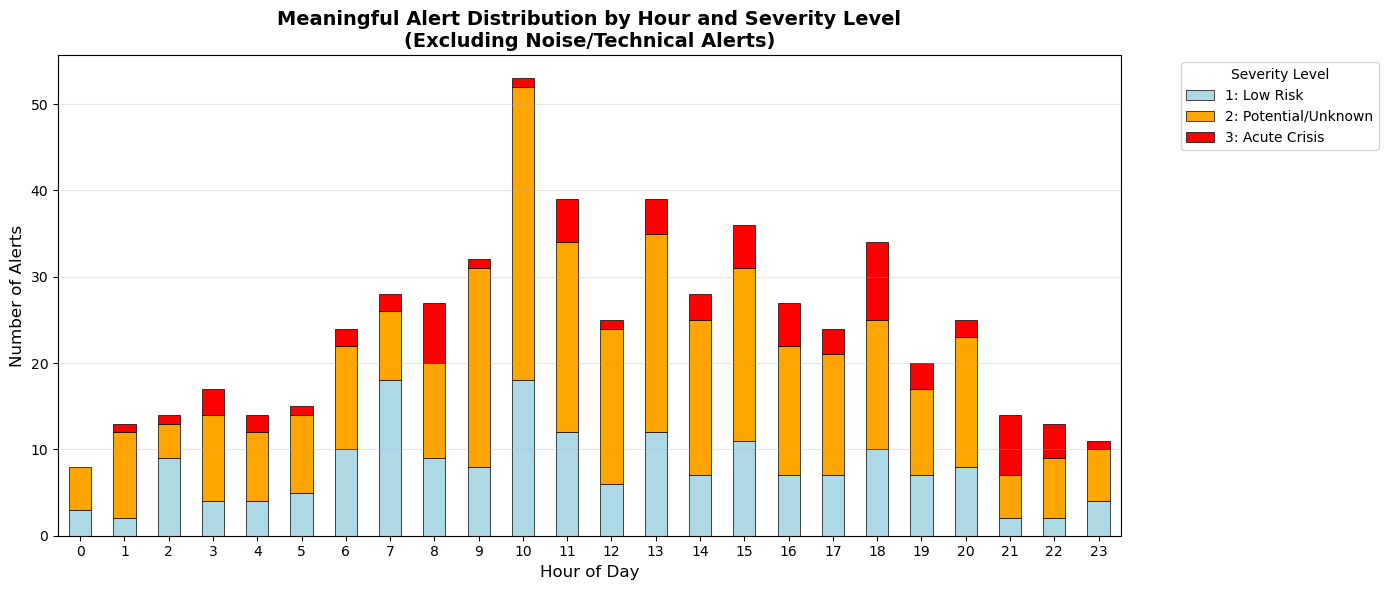


Detailed hourly breakdown by severity (excluding Noise/Tech):
severity_label  1: Low Risk  2: Potential/Unknown  3: Acute Crisis
hour                                                              
0                         3                     5                0
1                         2                    10                1
2                         9                     4                1
3                         4                    10                3
4                         4                     8                2
5                         5                     9                1
6                        10                    12                2
7                        18                     8                2
8                         9                    11                7
9                         8                    23                1
10                       18                    34                1
11                       12                    22                5

In [ ]:
severity_colors = {
    '1: Low Risk': 'lightblue',
    '2: Potential/Unknown': 'orange',
    '3: Acute Crisis': 'red'
}

for severity in severity_colors.keys():
    if severity not in hourly_pivot.columns:
        hourly_pivot[severity] = 0

column_order = ['1: Low Risk', '2: Potential/Unknown', '3: Acute Crisis']
hourly_pivot = hourly_pivot[[col for col in column_order if col in hourly_pivot.columns]]

fig, ax = plt.subplots(figsize=(14, 6))

hourly_pivot.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=[severity_colors.get(col, 'gray') for col in hourly_pivot.columns],
    edgecolor='black',
    linewidth=0.5
)

ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Number of Alerts', fontsize=12)
ax.set_title('Alert Distribution by Hour and Severity Level\n(Excluding Noise/Technical Alerts)', fontsize=14, fontweight='bold')
ax.set_xticks(range(24))
ax.set_xticklabels(range(24), rotation=0)
ax.legend(title='Severity Level', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
hourly_pivot.astype(int)

severity_label,1: Low Risk,2: Potential/Unknown,3: Acute Crisis
hour,,,
0,3,5,0
1,2,10,1
2,9,4,1
3,4,10,3
4,4,8,2
5,5,9,1
6,10,12,2
7,18,8,2
8,9,11,7


## 8.3 Peak hours analysis

Identify peak alert hours and patterns.

In [19]:
# Calculate total alerts per hour
hourly_totals = hourly_pivot.sum(axis=1).sort_values(ascending=False)

print("="*60)
print("TOP 5 PEAK ALERT HOURS")
print("="*60)
for hour, count in hourly_totals.head(5).items():
    print(f"Hour {hour:02d}:00 - {count:.0f} alerts")
    # Show severity breakdown for this hour
    for severity in hourly_pivot.columns:
        severity_count = hourly_pivot.loc[hour, severity]
        if severity_count > 0:
            print(f"  - {severity}: {severity_count:.0f}")

print("\n" + "="*60)
print("TOP 5 QUIETEST HOURS")
print("="*60)
for hour, count in hourly_totals.tail(5).items():
    print(f"Hour {hour:02d}:00 - {count:.0f} alerts")

# Time period analysis
print("\n" + "="*60)
print("ALERT DISTRIBUTION BY TIME PERIOD")
print("="*60)

time_periods = {
    'Night (00:00-05:59)': range(0, 6),
    'Morning (06:00-11:59)': range(6, 12),
    'Afternoon (12:00-17:59)': range(12, 18),
    'Evening (18:00-23:59)': range(18, 24)
}

for period_name, hours in time_periods.items():
    period_alerts = hourly_totals[list(hours)].sum()
    period_percentage = (period_alerts / hourly_totals.sum()) * 100
    print(f"{period_name}: {period_alerts:.0f} alerts ({period_percentage:.1f}%)")

TOP 5 PEAK ALERT HOURS
Hour 10:00 - 53 alerts
  - 1: Low Risk: 18
  - 2: Potential/Unknown: 34
  - 3: Acute Crisis: 1
Hour 11:00 - 39 alerts
  - 1: Low Risk: 12
  - 2: Potential/Unknown: 22
  - 3: Acute Crisis: 5
Hour 13:00 - 39 alerts
  - 1: Low Risk: 12
  - 2: Potential/Unknown: 23
  - 3: Acute Crisis: 4
Hour 15:00 - 36 alerts
  - 1: Low Risk: 11
  - 2: Potential/Unknown: 20
  - 3: Acute Crisis: 5
Hour 18:00 - 34 alerts
  - 1: Low Risk: 10
  - 2: Potential/Unknown: 15
  - 3: Acute Crisis: 9

TOP 5 QUIETEST HOURS
Hour 02:00 - 14 alerts
Hour 22:00 - 13 alerts
Hour 01:00 - 13 alerts
Hour 23:00 - 11 alerts
Hour 00:00 - 8 alerts

ALERT DISTRIBUTION BY TIME PERIOD
Night (00:00-05:59): 81 alerts (14.0%)
Morning (06:00-11:59): 203 alerts (35.0%)
Afternoon (12:00-17:59): 179 alerts (30.9%)
Evening (18:00-23:59): 117 alerts (20.2%)
